## Task 2 — Customer Segmentation Using Unsupervised Learning

**Dataset:** Mall Customers Dataset  
**Goal:** Cluster customers by spending habits and propose targeted marketing strategies.

---

**Topics:** K-Means Clustering · PCA · t-SNE · EDA · Customer Segmentation · Strategy Development


## · Install Dependencies


In [1]:
import subprocess, sys

packages = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]

for pkg in packages:
    print(f"Installing {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           pkg, "-q", "--disable-pip-version-check"])

print("\n All packages installed successfully!")


Installing pandas ...
Installing numpy ...
Installing matplotlib ...
Installing seaborn ...
Installing scikit-learn ...

 All packages installed successfully!


## 1 · Imports & Global Theme


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

OBSIDIAN  = "#0d1117"
SURFACE   = "#161b22"
SURFACE2  = "#21262d"
BORDER    = "#30363d"
TEXT      = "#e6edf3"
TEXT_MUTED= "#8b949e"
BLUE      = "#58a6ff"
GREEN     = "#39d353"
RED       = "#f85149"
VIOLET    = "#d2a8ff"
ORANGE    = "#ffa657"
YELLOW    = "#e3b341"
TEAL      = "#56d364"

CLUSTER_COLORS = [BLUE, GREEN, RED, VIOLET, ORANGE, YELLOW, TEAL, "#ff7b72"]

plt.rcParams.update({
    "figure.facecolor": OBSIDIAN,
    "axes.facecolor":   SURFACE,
    "axes.edgecolor":   BORDER,
    "axes.labelcolor":  TEXT,
    "axes.titlecolor":  TEXT,
    "axes.grid":        True,
    "grid.color":       SURFACE2,
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "text.color":       TEXT,
    "xtick.color":      TEXT_MUTED,
    "ytick.color":      TEXT_MUTED,
    "legend.facecolor": SURFACE,
    "legend.edgecolor": BORDER,
    "legend.labelcolor":TEXT,
    "font.family":      "monospace",
})

print(" Imports complete.")


 Imports complete.


## 2 · Load Dataset


In [ ]:
import urllib.request, os


mirrors = [
    "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv",
    "https://raw.githubusercontent.com/amankharwal/Website-data/master/Mall_Customers.csv",
    "https://raw.githubusercontent.com/krishnaik06/Mall-Customers-Segmentation/master/Mall_Customers.csv",
]

path = "Mall_Customers.csv"

if not os.path.exists(path):
    downloaded = False
    for url in mirrors:
        try:
            print(f"Trying: {url[:60]}...")
            urllib.request.urlretrieve(url, path)
            print("Downloaded ")
            downloaded = True
            break
        except Exception as e:
            print(f"  Failed: {e}")
    if not downloaded:
        raise RuntimeError("All mirrors failed. See manual download instructions below.")
else:
    print("File already exists ")

df = pd.read_csv(path)

# Standardise column names
df.columns = ["CustomerID", "Gender", "Age", "AnnualIncome", "SpendingScore"]

print(f"\nShape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
df.head(10)


File already exists 

Shape   : (200, 5)
Columns : ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']

Missing values:
CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64

Data types:
CustomerID       int64
Gender             str
Age              int64
AnnualIncome     int64
SpendingScore    int64
dtype: object


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



### 2a · Descriptive Statistics


In [6]:
print("── Numerical Summary ──────────────────────────────────")
print(df.describe().to_string())
print(f"\n── Gender Distribution ────────────────────────────────")
print(df["Gender"].value_counts())
print(f"\nMale   : {(df['Gender']=='Male').mean()*100:.1f}%")
print(f"Female : {(df['Gender']=='Female').mean()*100:.1f}%")


── Numerical Summary ──────────────────────────────────
       CustomerID         Age  AnnualIncome  SpendingScore
count  200.000000  200.000000    200.000000     200.000000
mean   100.500000   38.850000     60.560000      50.200000
std     57.879185   13.969007     26.264721      25.823522
min      1.000000   18.000000     15.000000       1.000000
25%     50.750000   28.750000     41.500000      34.750000
50%    100.500000   36.000000     61.500000      50.000000
75%    150.250000   49.000000     78.000000      73.000000
max    200.000000   70.000000    137.000000      99.000000

── Gender Distribution ────────────────────────────────
Gender
Female    112
Male       88
Name: count, dtype: int64

Male   : 44.0%
Female : 56.0%



### 2b · Feature Distributions


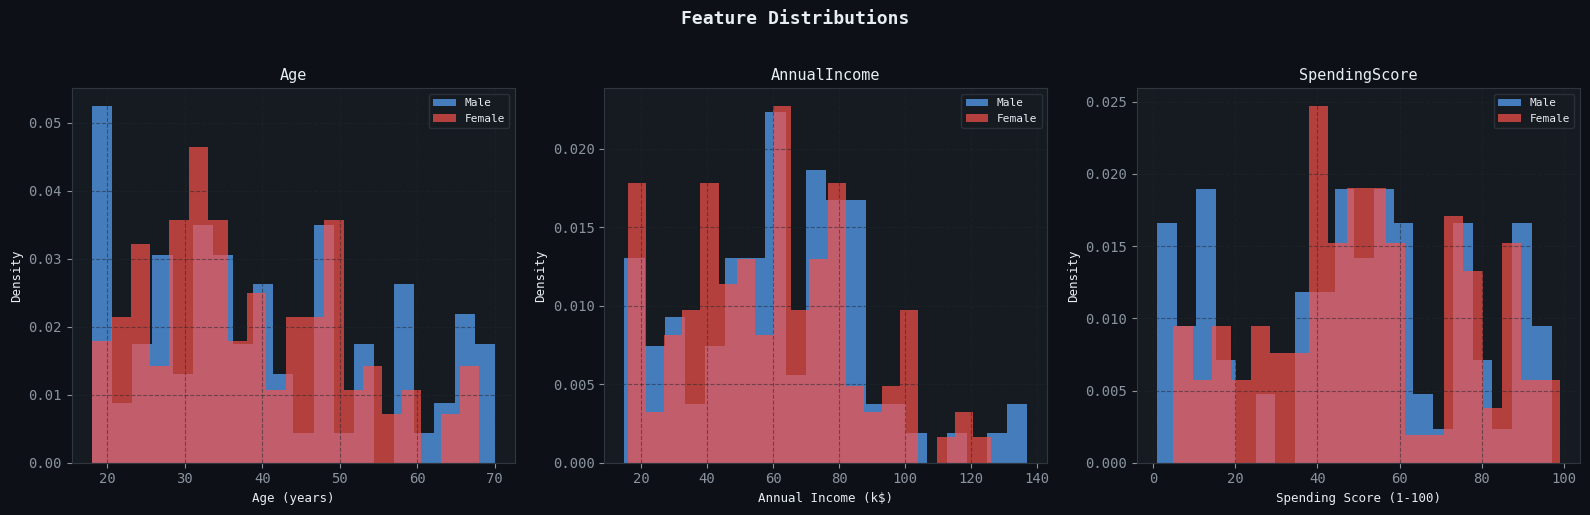

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Feature Distributions", fontsize=13, color=TEXT,
             fontweight="bold", y=1.02)

num_features = ["Age", "AnnualIncome", "SpendingScore"]
colors       = [BLUE, GREEN, VIOLET]
xlabels      = ["Age (years)", "Annual Income (k$)", "Spending Score (1-100)"]

for ax, feat, clr, xlbl in zip(axes, num_features, colors, xlabels):
    male   = df.loc[df["Gender"] == "Male",   feat]
    female = df.loc[df["Gender"] == "Female", feat]
    ax.hist(male,   bins=20, alpha=0.7, color=BLUE,   label="Male",   density=True)
    ax.hist(female, bins=20, alpha=0.7, color=RED,    label="Female", density=True)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel(xlbl, fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


### 2c · Scatter Relationships & Correlation


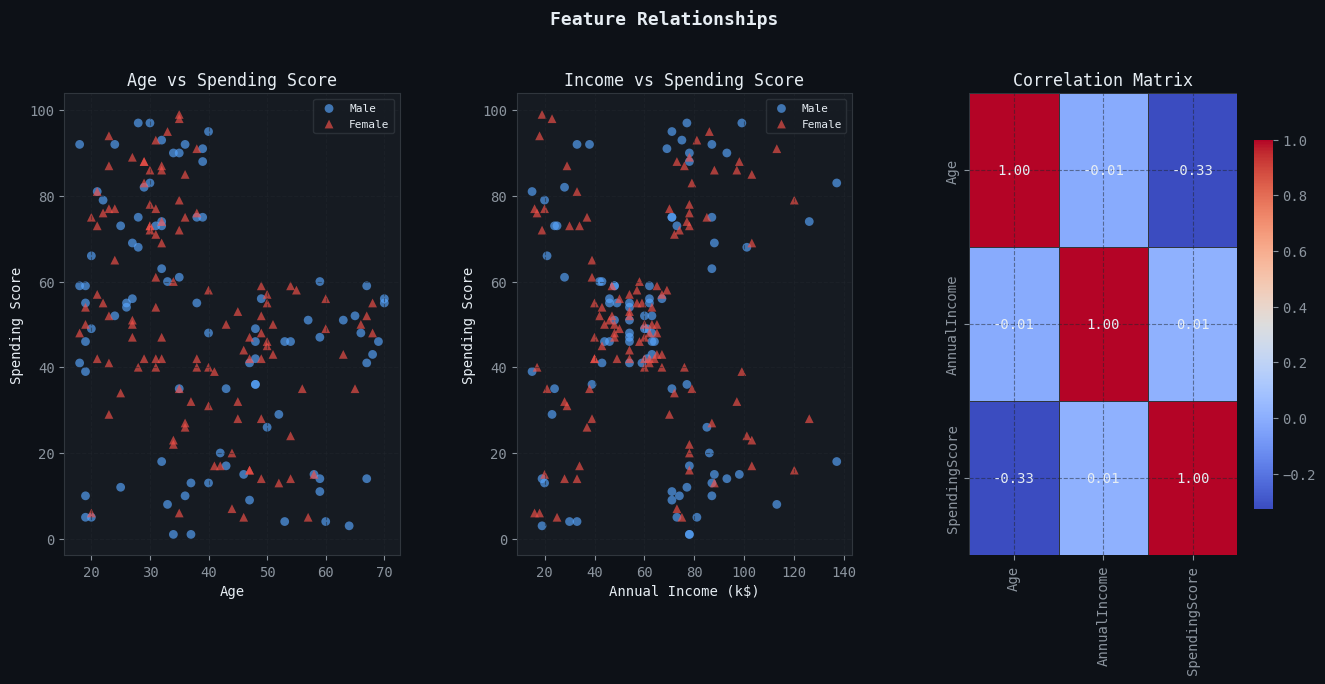

In [8]:
fig = plt.figure(figsize=(16, 6))
fig.suptitle("Feature Relationships", fontsize=13, color=TEXT, fontweight="bold", y=1.02)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Scatter 1: Age vs Spending Score
ax1 = fig.add_subplot(gs[0])
for g, c, m in [("Male", BLUE, "o"), ("Female", RED, "^")]:
    sub = df[df["Gender"] == g]
    ax1.scatter(sub["Age"], sub["SpendingScore"],
                c=c, marker=m, alpha=0.65, s=40, label=g, edgecolors="none")
ax1.set_xlabel("Age"); ax1.set_ylabel("Spending Score")
ax1.set_title("Age vs Spending Score"); ax1.legend(fontsize=8)

# Scatter 2: Income vs Spending Score
ax2 = fig.add_subplot(gs[1])
for g, c, m in [("Male", BLUE, "o"), ("Female", RED, "^")]:
    sub = df[df["Gender"] == g]
    ax2.scatter(sub["AnnualIncome"], sub["SpendingScore"],
                c=c, marker=m, alpha=0.65, s=40, label=g, edgecolors="none")
ax2.set_xlabel("Annual Income (k$)"); ax2.set_ylabel("Spending Score")
ax2.set_title("Income vs Spending Score"); ax2.legend(fontsize=8)

# Correlation heatmap
ax3 = fig.add_subplot(gs[2])
corr = df[["Age", "AnnualIncome", "SpendingScore"]].corr()
sns.heatmap(corr, ax=ax3, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, linecolor=BORDER,
            annot_kws={"size": 10, "color": TEXT},
            cbar_kws={"shrink": 0.8})
ax3.set_title("Correlation Matrix")

for ax in [ax1, ax2, ax3]:
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.savefig("eda_relationships.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()



### 2d · Boxplots by Gender


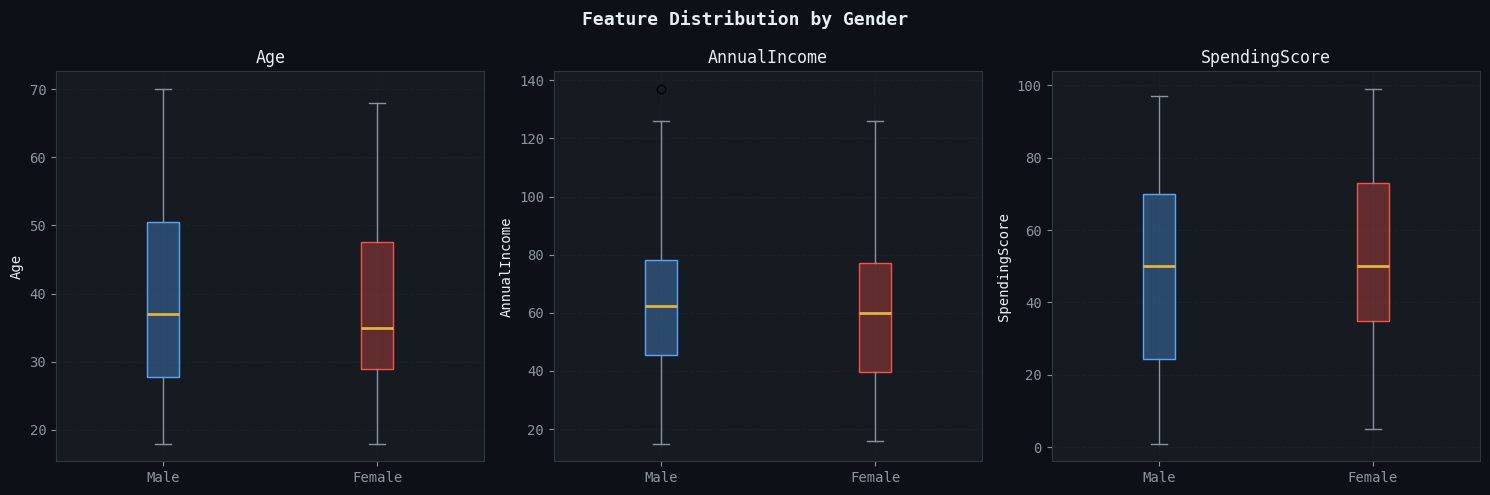

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Feature Distribution by Gender", fontsize=13, color=TEXT, fontweight="bold")

for ax, feat in zip(axes, ["Age", "AnnualIncome", "SpendingScore"]):
    data_m = df.loc[df["Gender"] == "Male",   feat]
    data_f = df.loc[df["Gender"] == "Female", feat]
    bp = ax.boxplot([data_m, data_f], patch_artist=True,
                    medianprops=dict(color=YELLOW, linewidth=2))
    bp["boxes"][0].set_facecolor(BLUE  + "55")
    bp["boxes"][1].set_facecolor(RED   + "55")
    bp["boxes"][0].set_edgecolor(BLUE)
    bp["boxes"][1].set_edgecolor(RED)
    for whisker in bp["whiskers"]: whisker.set_color(TEXT_MUTED)
    for cap     in bp["caps"]:     cap.set_color(TEXT_MUTED)
    for flier   in bp["fliers"]:   flier.set(marker="o", color=TEXT_MUTED, alpha=0.5)
    ax.set_xticklabels(["Male", "Female"])
    ax.set_title(feat); ax.set_ylabel(feat)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


## 3 · Preprocessing — Feature Selection & Scaling

We cluster on **Annual Income** and **Spending Score** (2-D) for intuitive interpretation,
then also on all 3 numerical features (3-D) for a richer segmentation.


In [10]:
# ── 2-feature clustering (Income + Spending) ─────────────────
features_2d = ["AnnualIncome", "SpendingScore"]
X_2d        = df[features_2d].values

# ── 3-feature clustering (Age + Income + Spending) ───────────
features_3d = ["Age", "AnnualIncome", "SpendingScore"]
X_3d_raw    = df[features_3d].values

scaler   = StandardScaler()
X_3d     = scaler.fit_transform(X_3d_raw)

print("2-D feature matrix shape :", X_2d.shape)
print("3-D feature matrix shape :", X_3d.shape)
print("\nFeatures for 2-D clustering:", features_2d)
print("Features for 3-D clustering:", features_3d)


2-D feature matrix shape : (200, 2)
3-D feature matrix shape : (200, 3)

Features for 2-D clustering: ['AnnualIncome', 'SpendingScore']
Features for 3-D clustering: ['Age', 'AnnualIncome', 'SpendingScore']



## 4 · Finding Optimal K — Elbow Method & Silhouette Score


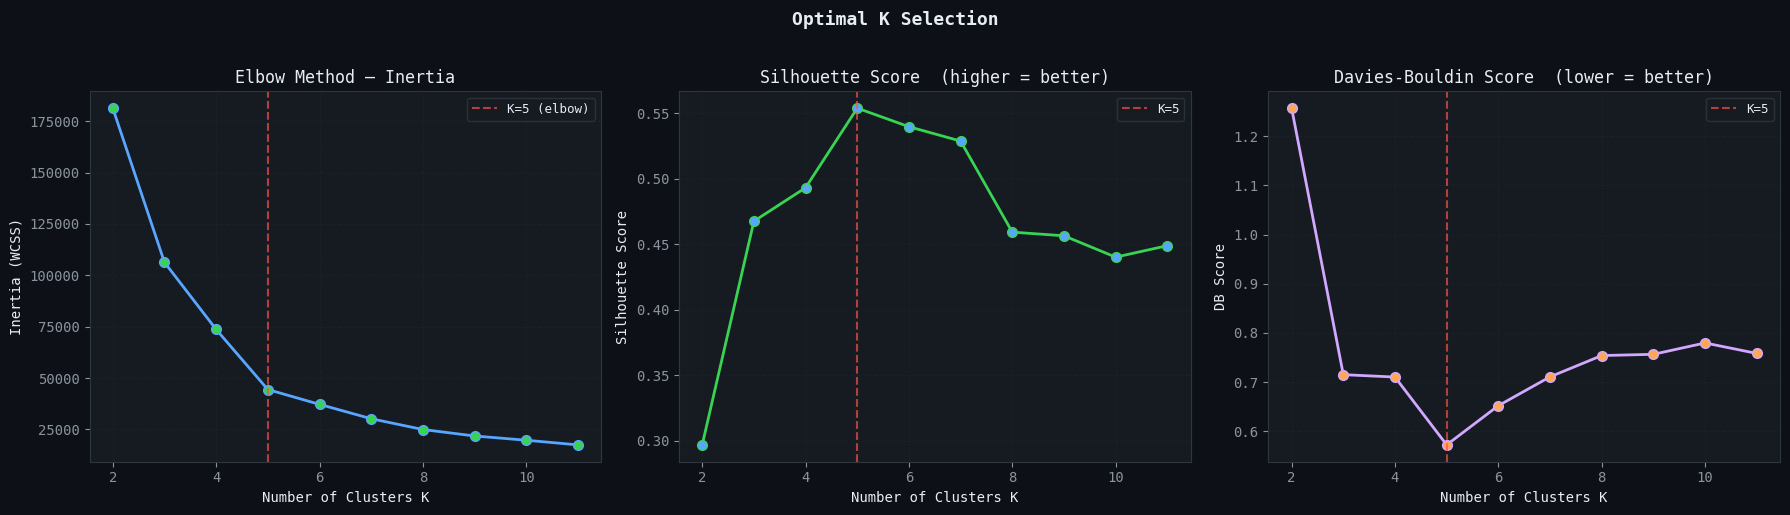

   K      Inertia   Silhouette   Davies-Bouldin
------------------------------------------------
   2     181363.6       0.2969           1.2568
   3     106348.4       0.4676           0.7153
   4      73679.8       0.4932           0.7104
   5      44448.5       0.5539           0.5726
   6      37233.8       0.5398           0.6522
   7      30241.3       0.5288           0.7108
   8      24996.0       0.4593           0.7541
   9      21850.2       0.4565           0.7566
  10      19779.0       0.4402           0.7797
  11      17511.7       0.4490           0.7584


In [11]:
k_range  = range(2, 12)
inertias = []
sil_scores = []
db_scores  = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = km.fit_predict(X_2d)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_2d, labels))
    db_scores.append(davies_bouldin_score(X_2d, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Optimal K Selection", fontsize=13, color=TEXT, fontweight="bold", y=1.02)

# Elbow
axes[0].plot(k_range, inertias, "o-", color=BLUE, lw=2, ms=7, markerfacecolor=GREEN)
axes[0].axvline(x=5, color=RED, linestyle="--", alpha=0.7, label="K=5 (elbow)")
axes[0].set_title("Elbow Method — Inertia")
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].legend(fontsize=9)

# Silhouette
axes[1].plot(k_range, sil_scores, "o-", color=GREEN, lw=2, ms=7, markerfacecolor=BLUE)
axes[1].axvline(x=5, color=RED, linestyle="--", alpha=0.7, label="K=5")
axes[1].set_title("Silhouette Score  (higher = better)")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend(fontsize=9)

# Davies-Bouldin
axes[2].plot(k_range, db_scores, "o-", color=VIOLET, lw=2, ms=7, markerfacecolor=ORANGE)
axes[2].axvline(x=5, color=RED, linestyle="--", alpha=0.7, label="K=5")
axes[2].set_title("Davies-Bouldin Score  (lower = better)")
axes[2].set_xlabel("Number of Clusters K")
axes[2].set_ylabel("DB Score")
axes[2].legend(fontsize=9)

for ax in axes:
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("optimal_k.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()

# Print scores table
print(f"{'K':>4} {'Inertia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-" * 48)
for k, ine, sil, db in zip(k_range, inertias, sil_scores, db_scores):
    print(f"{k:>4} {ine:>12.1f} {sil:>12.4f} {db:>16.4f}")


## 5 · K-Means Clustering  (K = 5)


In [12]:
OPTIMAL_K = 5

# ── 2-D clustering ────────────────────────────────────────────
km_2d   = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=20, random_state=42)
labels_2d = km_2d.fit_predict(X_2d)
df["Cluster_2D"] = labels_2d

# ── 3-D clustering ────────────────────────────────────────────
km_3d   = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=20, random_state=42)
labels_3d = km_3d.fit_predict(X_3d)
df["Cluster_3D"] = labels_3d

sil_2d = silhouette_score(X_2d, labels_2d)
sil_3d = silhouette_score(X_3d, labels_3d)

print(f"K = {OPTIMAL_K}")
print(f"Silhouette Score — 2-D clustering : {sil_2d:.4f}")
print(f"Silhouette Score — 3-D clustering : {sil_3d:.4f}")
print(f"\n── Cluster sizes (2-D) ─────────────────")
print(df["Cluster_2D"].value_counts().sort_index().to_string())


K = 5
Silhouette Score — 2-D clustering : 0.5539
Silhouette Score — 3-D clustering : 0.4166

── Cluster sizes (2-D) ─────────────────
Cluster_2D
0    81
1    39
2    22
3    35
4    23


### 5a · 2-D Cluster Visualization — Income vs Spending Score


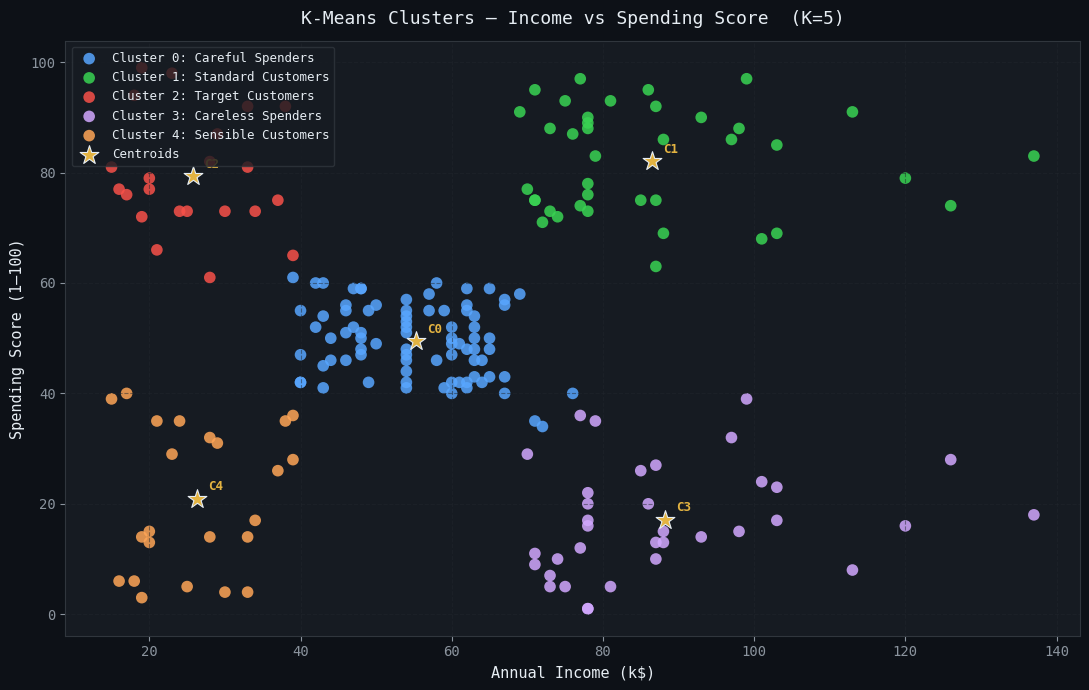

In [13]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(OBSIDIAN)
ax.set_facecolor(SURFACE)

segment_names = {
    0: "Careful Spenders",
    1: "Standard Customers",
    2: "Target Customers",
    3: "Careless Spenders",
    4: "Sensible Customers",
}

for cluster_id in range(OPTIMAL_K):
    mask = df["Cluster_2D"] == cluster_id
    ax.scatter(df.loc[mask, "AnnualIncome"],
               df.loc[mask, "SpendingScore"],
               c=CLUSTER_COLORS[cluster_id], s=70, alpha=0.85,
               edgecolors="none", label=f"Cluster {cluster_id}: {segment_names[cluster_id]}")

# Plot centroids
cx = km_2d.cluster_centers_[:, 0]
cy = km_2d.cluster_centers_[:, 1]
ax.scatter(cx, cy, c=YELLOW, s=200, marker="*", zorder=5,
           edgecolors=TEXT, linewidths=0.8, label="Centroids")

for i, (x, y) in enumerate(zip(cx, cy)):
    ax.annotate(f"C{i}", (x, y), textcoords="offset points",
                xytext=(8, 6), fontsize=9, color=YELLOW, fontweight="bold")

ax.set_xlabel("Annual Income (k$)", fontsize=11)
ax.set_ylabel("Spending Score (1–100)", fontsize=11)
ax.set_title("K-Means Clusters — Income vs Spending Score  (K=5)",
             fontsize=13, pad=12)
ax.legend(loc="upper left", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("kmeans_2d.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


### 5b · Cluster Profiles — Mean Feature Values


── Cluster Profiles ────────────────────────────────────────────────
             Age  AnnualIncome  SpendingScore  Count  % Total
Cluster_2D                                                   
0           42.7          55.3           49.5     81     40.5
1           32.7          86.5           82.1     39     19.5
2           25.3          25.7           79.4     22     11.0
3           41.1          88.2           17.1     35     17.5
4           45.2          26.3           20.9     23     11.5


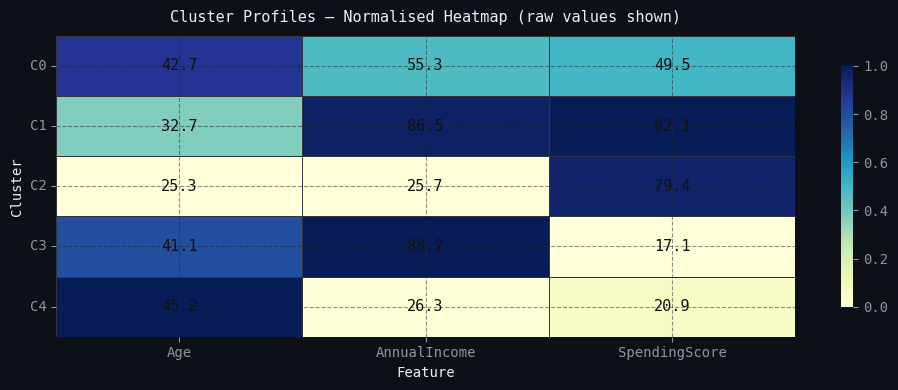

In [14]:
profile = df.groupby("Cluster_2D")[["Age", "AnnualIncome", "SpendingScore"]].mean().round(1)
profile["Count"]  = df["Cluster_2D"].value_counts().sort_index()
profile["% Total"] = (profile["Count"] / len(df) * 100).round(1)

print("── Cluster Profiles ────────────────────────────────────────────────")
print(profile.to_string())

# Visual heatmap of profiles
fig, ax = plt.subplots(figsize=(10, 4))
norm_profile = profile[["Age","AnnualIncome","SpendingScore"]].copy()
for col in norm_profile.columns:
    norm_profile[col] = (norm_profile[col] - norm_profile[col].min()) /                         (norm_profile[col].max() - norm_profile[col].min())

sns.heatmap(norm_profile, ax=ax, annot=profile[["Age","AnnualIncome","SpendingScore"]],
            fmt=".1f", cmap="YlGnBu", linewidths=0.5, linecolor=BORDER,
            annot_kws={"size": 11, "color": "#111"},
            cbar_kws={"shrink": 0.8})
ax.set_title("Cluster Profiles — Normalised Heatmap (raw values shown)",
             fontsize=11, pad=10)
ax.set_xlabel("Feature"); ax.set_ylabel("Cluster")
ax.set_yticklabels([f"C{i}" for i in range(OPTIMAL_K)], rotation=0)
plt.tight_layout()
plt.savefig("cluster_profiles.png", dpi=140, bbox_inches="tight", facecolor="white")
plt.show()


## 6 · Dimensionality Reduction — PCA
PCA projects the 3-D scaled feature space to 2-D while preserving maximum variance.


PC1 explained variance : 44.3%
PC2 explained variance : 33.3%
Total variance retained: 77.6%

PCA components (loadings):
                    PC1       PC2
Age            0.706382  0.030141
AnnualIncome  -0.048024  0.998832
SpendingScore -0.706199 -0.037775


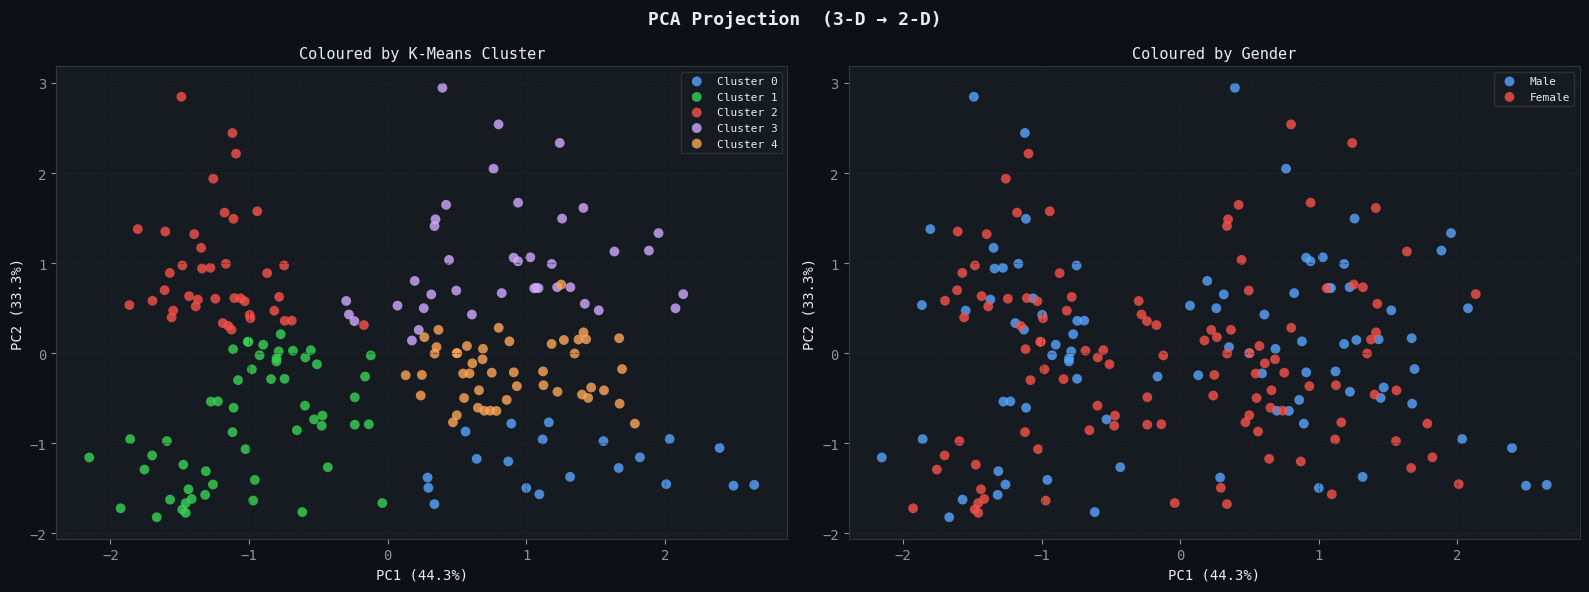

In [15]:
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_3d)

exp_var  = pca.explained_variance_ratio_
print(f"PC1 explained variance : {exp_var[0]*100:.1f}%")
print(f"PC2 explained variance : {exp_var[1]*100:.1f}%")
print(f"Total variance retained: {sum(exp_var)*100:.1f}%")
print(f"\nPCA components (loadings):")
loadings = pd.DataFrame(pca.components_.T,
                         index=features_3d,
                         columns=["PC1", "PC2"])
print(loadings.to_string())

# ── PCA scatter ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA Projection  (3-D → 2-D)", fontsize=13, color=TEXT, fontweight="bold")

for ax, label_col, title in zip(
        axes,
        ["Cluster_3D", "Gender"],
        ["Coloured by K-Means Cluster", "Coloured by Gender"]):

    if label_col == "Cluster_3D":
        groups = df[label_col].unique()
        for g in sorted(groups):
            mask = df[label_col] == g
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=CLUSTER_COLORS[g], s=50, alpha=0.8,
                       edgecolors="none", label=f"Cluster {g}")
    else:
        for g, c in [("Male", BLUE), ("Female", RED)]:
            mask = df[label_col] == g
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=c, s=50, alpha=0.8, edgecolors="none", label=g)

    ax.set_xlabel(f"PC1 ({exp_var[0]*100:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({exp_var[1]*100:.1f}%)", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


### 6a · PCA Scree Plot & Loadings Biplot


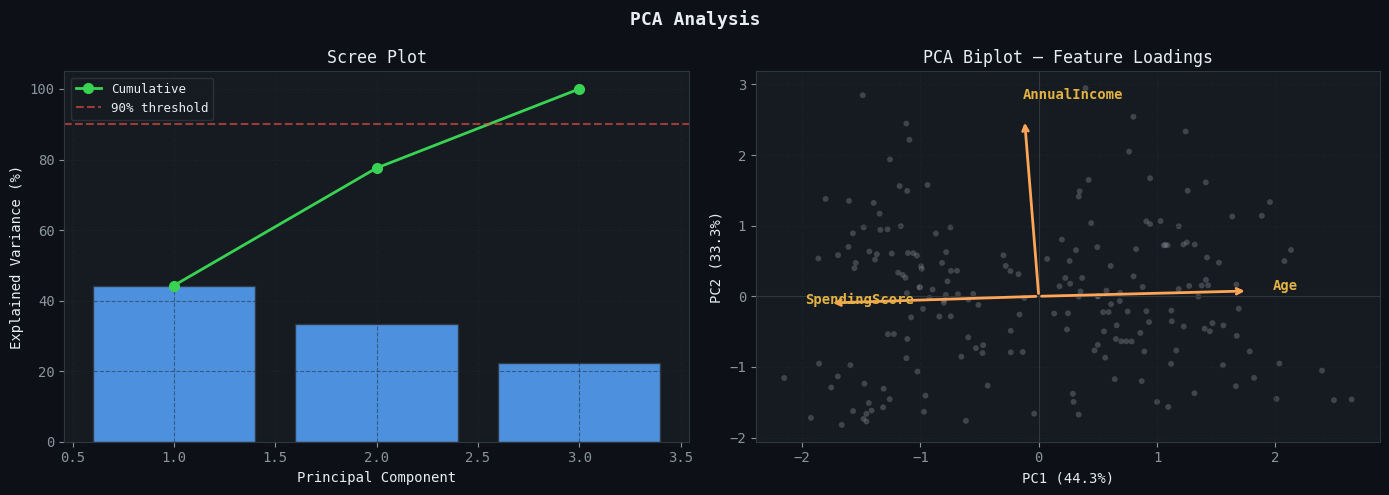

In [16]:
pca_full = PCA(random_state=42)
pca_full.fit(X_3d)
ev = pca_full.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA Analysis", fontsize=13, color=TEXT, fontweight="bold")

# Scree
axes[0].bar(range(1, len(ev)+1), ev*100, color=BLUE, alpha=0.85, edgecolor=BORDER)
axes[0].plot(range(1, len(ev)+1), np.cumsum(ev)*100, "o-", color=GREEN,
             lw=2, ms=7, label="Cumulative")
axes[0].axhline(90, color=RED, linestyle="--", alpha=0.6, label="90% threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")
axes[0].legend(fontsize=9)

# Biplot (loadings)
axes[1].set_facecolor(SURFACE)
scale = 2.5
for i, feat in enumerate(features_3d):
    axes[1].annotate("", xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                     xytext=(0,0),
                     arrowprops=dict(arrowstyle="->", color=ORANGE, lw=2))
    axes[1].text(pca.components_[0,i]*scale*1.12,
                 pca.components_[1,i]*scale*1.12,
                 feat, color=YELLOW, fontsize=10, fontweight="bold")

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=TEXT_MUTED, s=18, alpha=0.35, edgecolors="none")
axes[1].set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); axes[1].set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
axes[1].set_title("PCA Biplot — Feature Loadings")
axes[1].axhline(0, color=BORDER, lw=0.8); axes[1].axvline(0, color=BORDER, lw=0.8)

for ax in axes:
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("pca_scree_biplot.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


## 7 · Dimensionality Reduction — t-SNE
t-SNE captures **non-linear** structure. Great for visual cluster validation.


PC1 explained variance : 44.3%
PC2 explained variance : 33.3%
Total variance retained: 77.6%

PCA components (loadings):
                    PC1       PC2
Age            0.706382  0.030141
AnnualIncome  -0.048024  0.998832
SpendingScore -0.706199 -0.037775


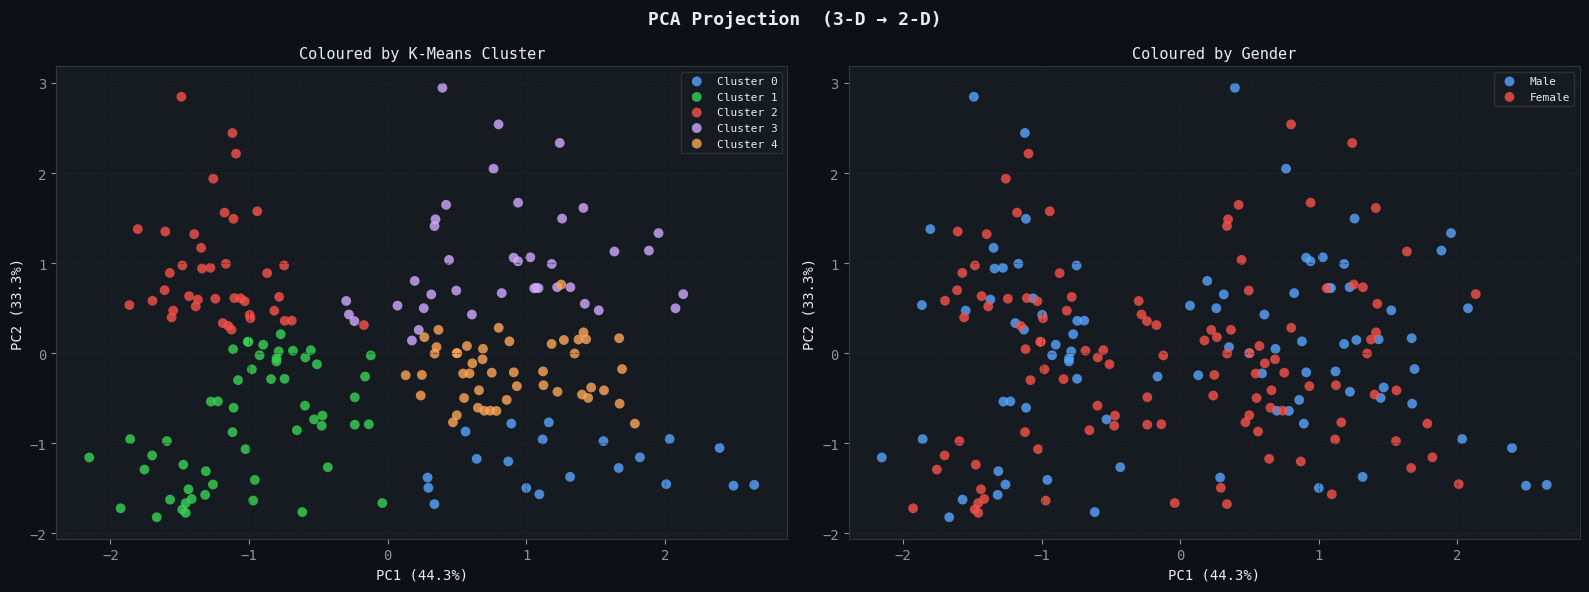

In [18]:
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_3d)

exp_var  = pca.explained_variance_ratio_
print(f"PC1 explained variance : {exp_var[0]*100:.1f}%")
print(f"PC2 explained variance : {exp_var[1]*100:.1f}%")
print(f"Total variance retained: {sum(exp_var)*100:.1f}%")
print(f"\nPCA components (loadings):")
loadings = pd.DataFrame(pca.components_.T,
                         index=features_3d,
                         columns=["PC1", "PC2"])
print(loadings.to_string())

# ── PCA scatter ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA Projection  (3-D → 2-D)", fontsize=13, color=TEXT, fontweight="bold")

for ax, label_col, title in zip(
        axes,
        ["Cluster_3D", "Gender"],
        ["Coloured by K-Means Cluster", "Coloured by Gender"]):

    if label_col == "Cluster_3D":
        groups = df[label_col].unique()
        for g in sorted(groups):
            mask = df[label_col] == g
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=CLUSTER_COLORS[g], s=50, alpha=0.8,
                       edgecolors="none", label=f"Cluster {g}")
    else:
        for g, c in [("Male", BLUE), ("Female", RED)]:
            mask = df[label_col] == g
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=c, s=50, alpha=0.8, edgecolors="none", label=g)

    ax.set_xlabel(f"PC1 ({exp_var[0]*100:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({exp_var[1]*100:.1f}%)", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


### 7a · PCA vs t-SNE Side-by-Side Comparison


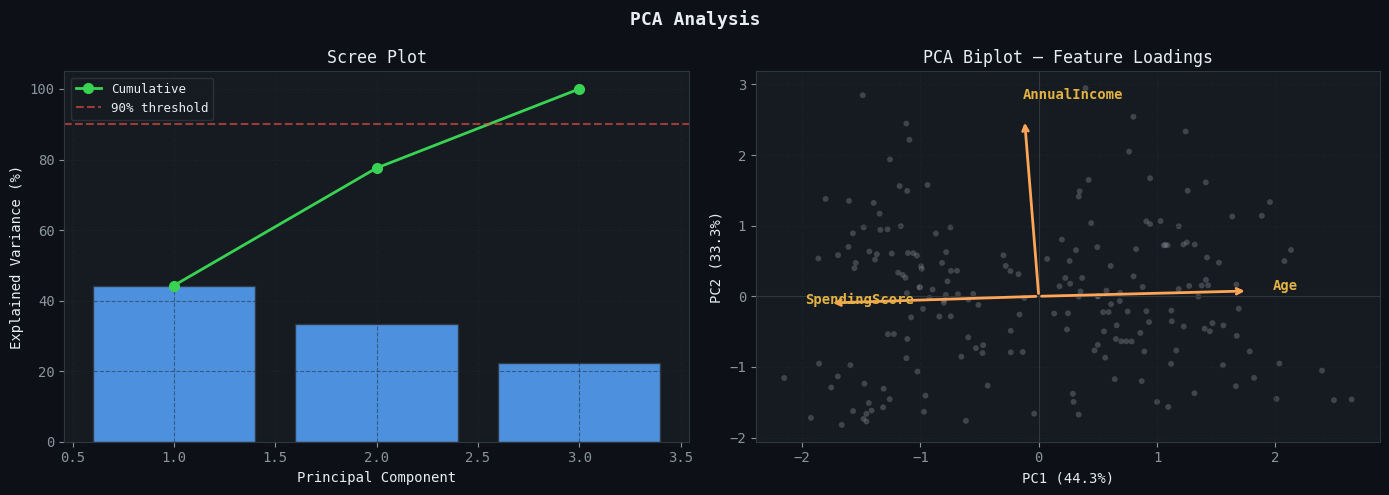

In [20]:
pca_full = PCA(random_state=42)
pca_full.fit(X_3d)
ev = pca_full.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA Analysis", fontsize=13, color=TEXT, fontweight="bold")

# Scree
axes[0].bar(range(1, len(ev)+1), ev*100, color=BLUE, alpha=0.85, edgecolor=BORDER)
axes[0].plot(range(1, len(ev)+1), np.cumsum(ev)*100, "o-", color=GREEN,
             lw=2, ms=7, label="Cumulative")
axes[0].axhline(90, color=RED, linestyle="--", alpha=0.6, label="90% threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")
axes[0].legend(fontsize=9)

# Biplot (loadings)
axes[1].set_facecolor(SURFACE)
scale = 2.5
for i, feat in enumerate(features_3d):
    axes[1].annotate("", xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                     xytext=(0,0),
                     arrowprops=dict(arrowstyle="->", color=ORANGE, lw=2))
    axes[1].text(pca.components_[0,i]*scale*1.12,
                 pca.components_[1,i]*scale*1.12,
                 feat, color=YELLOW, fontsize=10, fontweight="bold")

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=TEXT_MUTED, s=18, alpha=0.35, edgecolors="none")
axes[1].set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); axes[1].set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
axes[1].set_title("PCA Biplot — Feature Loadings")
axes[1].axhline(0, color=BORDER, lw=0.8); axes[1].axvline(0, color=BORDER, lw=0.8)

for ax in axes:
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("pca_scree_biplot.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


### 7b · Cluster Feature Distributions — Violin Plots


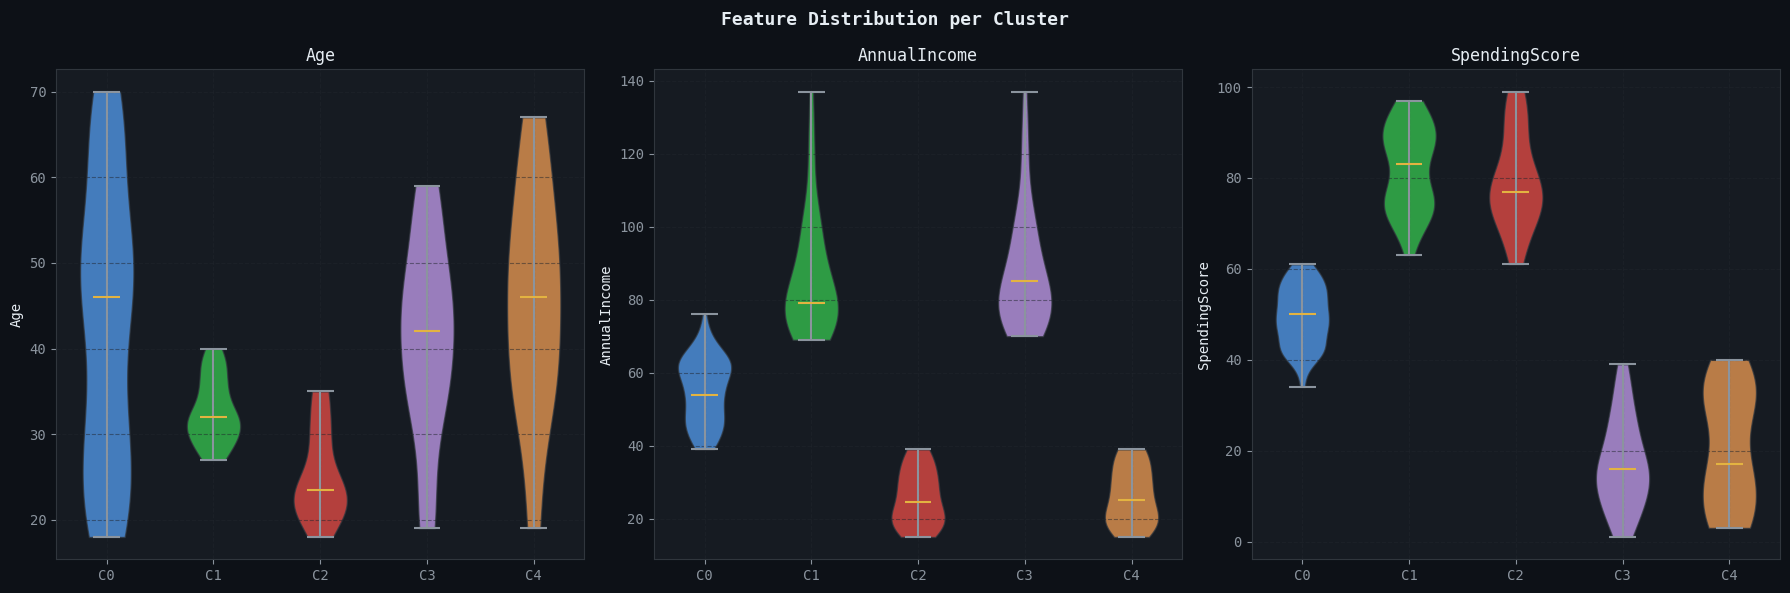

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Feature Distribution per Cluster", fontsize=13, color=TEXT, fontweight="bold")

for ax, feat in zip(axes, ["Age", "AnnualIncome", "SpendingScore"]):
    data_by_cluster = [df.loc[df["Cluster_2D"] == k, feat].values
                       for k in range(OPTIMAL_K)]
    vp = ax.violinplot(data_by_cluster, positions=range(OPTIMAL_K),
                       showmedians=True, showextrema=True)
    for i, body in enumerate(vp["bodies"]):
        body.set_facecolor(CLUSTER_COLORS[i])
        body.set_alpha(0.7)
        body.set_edgecolor(BORDER)
    vp["cmedians"].set_color(YELLOW)
    vp["cmins"].set_color(TEXT_MUTED)
    vp["cmaxes"].set_color(TEXT_MUTED)
    vp["cbars"].set_color(TEXT_MUTED)
    ax.set_xticks(range(OPTIMAL_K))
    ax.set_xticklabels([f"C{k}" for k in range(OPTIMAL_K)])
    ax.set_title(feat); ax.set_ylabel(feat)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("cluster_violin.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()



## 8 · Marketing Strategies per Customer Segment

Based on cluster profiles (income level × spending behaviour):


In [22]:
strategies = {
    0: {
        "name":     " High Income, Low Spending  —  Untapped Premium Segment",
        "profile":  "High earners who spend conservatively. Trust-focused, value-conscious.",
        "color":    BLUE,
        "tactics": [
            "➤ Offer exclusive premium loyalty programs to build trust",
            "➤ Highlight quality, durability and long-term value",
            "➤ Use personalised email campaigns with tailored product recommendations",
            "➤ Provide early access to new arrivals and VIP events",
            "➤ Focus on financial products: credit cards, investment packages",
        ]
    },
    1: {
        "name":     " Medium Income, Medium Spending  —  Standard Core Customers",
        "profile":  "Balanced spenders. Price-sensitive but brand-aware.",
        "color":    GREEN,
        "tactics": [
            "➤ Run seasonal discount campaigns and bundle deals",
            "➤ Implement point-based rewards and cashback programs",
            "➤ Use social proof — reviews, ratings, testimonials",
            "➤ Send push notifications for flash sales and limited offers",
            "➤ Cross-sell mid-range products during checkout",
        ]
    },
    2: {
        "name":     " High Income, High Spending  —  Prime Target Customers",
        "profile":  "Best customers. High earners who spend freely. Most valuable segment.",
        "color":    YELLOW,
        "tactics": [
            "➤ Invest heavily in retention — exclusive membership tiers",
            "➤ Offer premium concierge-level customer service",
            "➤ Launch new luxury product lines targeting this group first",
            "➤ Use personalised luxury brand collaborations",
            "➤ Reward referrals generously — they influence peer networks",
        ]
    },
    3: {
        "name":     " Low Income, High Spending  —  Impulsive / Trend Shoppers",
        "profile":  "Spend more than their income suggests. Driven by trends and impulse.",
        "color":    RED,
        "tactics": [
            "➤ Promote buy-now-pay-later (BNPL) and flexible instalment options",
            "➤ Leverage social media influencer marketing",
            "➤ Use limited-time flash sales and urgency triggers (countdown timers)",
            "➤ Gamify the shopping experience — spin-to-win, surprise rewards",
            "➤ Targeted ads on Instagram, TikTok for trend-driven products",
        ]
    },
    4: {
        "name":     " Low Income, Low Spending  —  Budget-Conscious Customers",
        "profile":  "Cautious spenders. Prioritise necessity over luxury.",
        "color":    VIOLET,
        "tactics": [
            "➤ Focus on essential everyday products at low price points",
            "➤ Promote strong discount events: Black Friday, year-end sales",
            "➤ Offer free shipping thresholds to increase basket size",
            "➤ Use value-messaging: 'Best bang for your buck'",
            "➤ Provide comparison tools to show savings vs competitors",
        ]
    },
}

# ── Print strategies ──────────────────────────────────────────
for k, info in strategies.items():
    print(f"\n{'═'*62}")
    print(f"  Cluster {k} · {info['name']}")
    print(f"{'─'*62}")
    print(f"  Profile : {info['profile']}")
    print(f"  Tactics :")
    for t in info["tactics"]:
        print(f"    {t}")
print(f"\n{'═'*62}")



══════════════════════════════════════════════════════════════
  Cluster 0 ·  High Income, Low Spending  —  Untapped Premium Segment
──────────────────────────────────────────────────────────────
  Profile : High earners who spend conservatively. Trust-focused, value-conscious.
  Tactics :
    ➤ Offer exclusive premium loyalty programs to build trust
    ➤ Highlight quality, durability and long-term value
    ➤ Use personalised email campaigns with tailored product recommendations
    ➤ Provide early access to new arrivals and VIP events
    ➤ Focus on financial products: credit cards, investment packages

══════════════════════════════════════════════════════════════
  Cluster 1 ·  Medium Income, Medium Spending  —  Standard Core Customers
──────────────────────────────────────────────────────────────
  Profile : Balanced spenders. Price-sensitive but brand-aware.
  Tactics :
    ➤ Run seasonal discount campaigns and bundle deals
    ➤ Implement point-based rewards and cashback progr

### 8a · Strategy Dashboard — Cluster Positioning Map


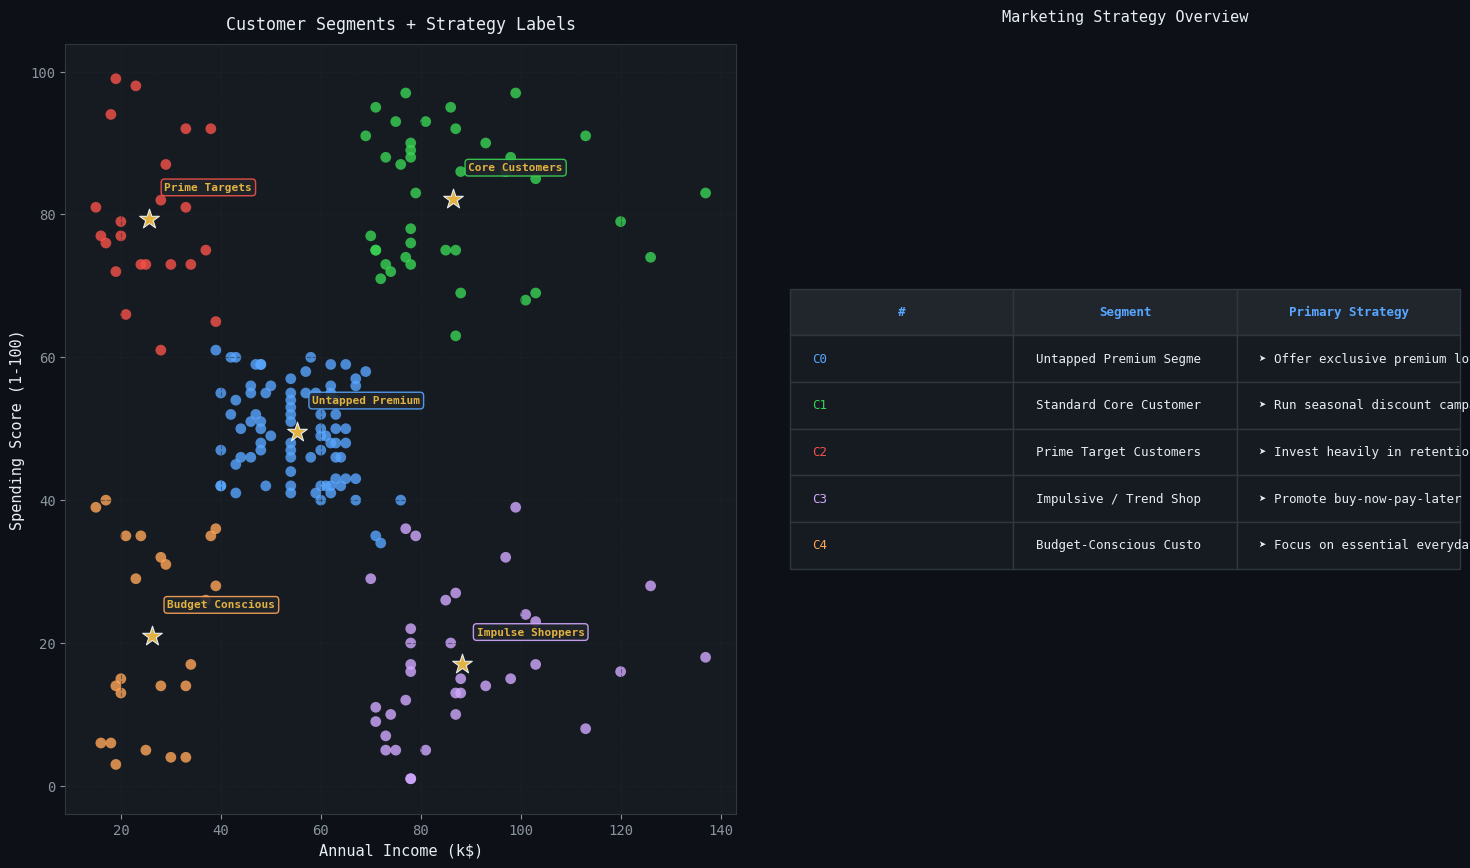

In [24]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(OBSIDIAN)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08)

# ── LEFT: cluster scatter with annotations ──────────────────────
ax_left = fig.add_subplot(gs[0])
ax_left.set_facecolor(SURFACE)

for cluster_id in range(OPTIMAL_K):
    mask = df["Cluster_2D"] == cluster_id
    ax_left.scatter(df.loc[mask, "AnnualIncome"],
                   df.loc[mask, "SpendingScore"],
                   c=CLUSTER_COLORS[cluster_id],
                   s=60, alpha=0.8, edgecolors="none")

cx = km_2d.cluster_centers_[:, 0]
cy = km_2d.cluster_centers_[:, 1]

# Short names — one string per cluster, no line breaks inside
short_names = [
    "Untapped Premium",
    "Core Customers",
    "Prime Targets",
    "Impulse Shoppers",
    "Budget Conscious",
]

for i in range(OPTIMAL_K):
    ax_left.scatter(cx[i], cy[i], c=YELLOW, s=220, marker="*",
                   zorder=6, edgecolors=TEXT, linewidths=0.8)
    ax_left.annotate(
        short_names[i],
        xy=(cx[i], cy[i]),
        xytext=(cx[i] + 3, cy[i] + 4),
        fontsize=8, color=YELLOW, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=SURFACE2,
                  edgecolor=CLUSTER_COLORS[i], alpha=0.9)
    )

ax_left.set_xlabel("Annual Income (k$)", fontsize=11)
ax_left.set_ylabel("Spending Score (1-100)", fontsize=11)
ax_left.set_title("Customer Segments + Strategy Labels", fontsize=12, pad=10)
for spine in ax_left.spines.values(): spine.set_edgecolor(BORDER)

# ── RIGHT: strategy summary table ───────────────────────────────
ax_right = fig.add_subplot(gs[1])
ax_right.set_facecolor(OBSIDIAN)
ax_right.axis("off")

table_data = []
for k, info in strategies.items():
    seg   = info["name"].split("—")[1].strip()[:22]
    tactic = info["tactics"][0].replace("> ", "")[:42] + "..."
    table_data.append([f"C{k}", seg, tactic])

tbl = ax_right.table(
    cellText=table_data,
    colLabels=["#", "Segment", "Primary Strategy"],
    loc="center",
    cellLoc="left"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.8)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:                                  # header row
        cell.set_facecolor(SURFACE2)
        cell.set_text_props(color=BLUE, fontweight="bold")
    else:                                       # data rows — r starts at 1
        cell.set_facecolor(SURFACE)
        col = CLUSTER_COLORS[r - 1] if c == 0 else TEXT
        cell.set_text_props(color=col)
    cell.set_edgecolor(BORDER)

ax_right.set_title("Marketing Strategy Overview", color=TEXT, fontsize=11, pad=16)

plt.savefig("strategy_dashboard.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


## 9 · Final Summary & Clustering Metrics


── Clustering Quality Metrics ──────────────────────────────────
  Silhouette Score (↑ better)                   : 0.5539
  Davies-Bouldin Score (↓ better)               : 0.5726
  Calinski-Harabasz Score (↑ better)            : 247.36

── Cluster Summary Table ───────────────────────────────────────
            Count  Avg_Age  Avg_Income  Avg_Spending                     Segment
Cluster_2D                                                                      
0              81     42.7        55.3          49.5    Untapped Premium Segment
1              39     32.7        86.5          82.1     Standard Core Customers
2              22     25.3        25.7          79.4      Prime Target Customers
3              35     41.1        88.2          17.1  Impulsive / Trend Shoppers
4              23     45.2        26.3          20.9  Budget-Conscious Customers


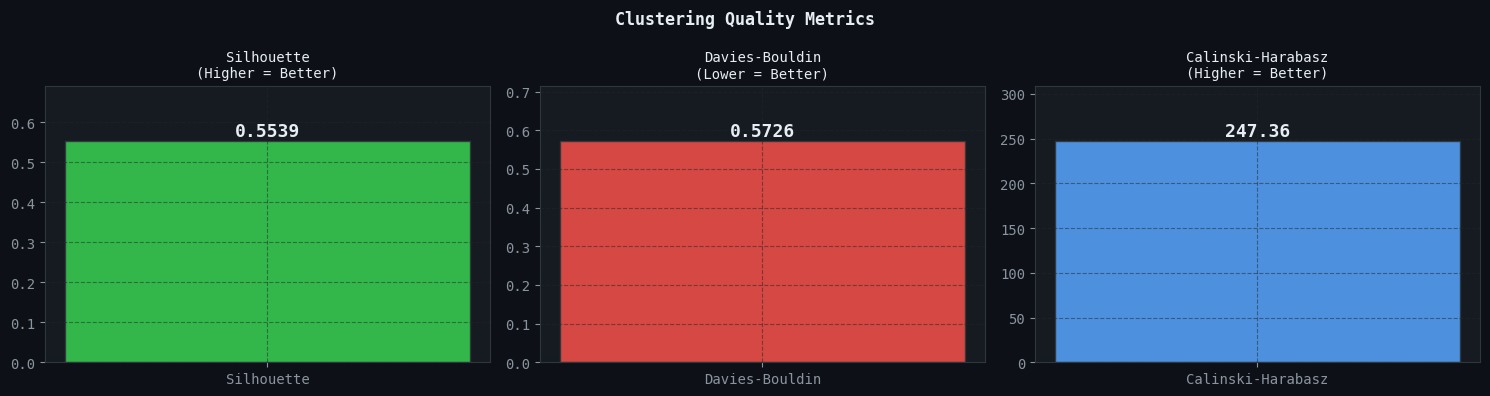


 Customer Segmentation Pipeline Complete


In [25]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

metrics = {
    "Silhouette Score (↑ better)":        round(silhouette_score(X_2d, labels_2d), 4),
    "Davies-Bouldin Score (↓ better)":    round(davies_bouldin_score(X_2d, labels_2d), 4),
    "Calinski-Harabasz Score (↑ better)": round(calinski_harabasz_score(X_2d, labels_2d), 2),
}

print("── Clustering Quality Metrics ──────────────────────────────────")
for name, val in metrics.items():
    print(f"  {name:45s} : {val}")

print("\n── Cluster Summary Table ───────────────────────────────────────")
summary = df.groupby("Cluster_2D").agg(
    Count        = ("CustomerID", "count"),
    Avg_Age      = ("Age", "mean"),
    Avg_Income   = ("AnnualIncome", "mean"),
    Avg_Spending = ("SpendingScore", "mean"),
).round(1)
summary["Segment"] = [strategies[k]["name"].split("—")[1].strip() for k in summary.index]
print(summary.to_string())

# Final visual metrics bar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Clustering Quality Metrics", fontsize=12, color=TEXT, fontweight="bold")

metric_names = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
metric_vals  = list(metrics.values())
metric_clrs  = [GREEN, RED, BLUE]
metric_note  = ["Higher = Better", "Lower = Better", "Higher = Better"]

for ax, name, val, clr, note in zip(axes, metric_names, metric_vals, metric_clrs, metric_note):
    ax.bar([name], [val], color=clr, alpha=0.85, edgecolor=BORDER)
    ax.text(0, val + val*0.02, str(val), ha="center", fontsize=13, color=TEXT, fontweight="bold")
    ax.set_title(f"{name}\n({note})", fontsize=10)
    ax.set_ylim(0, val * 1.25)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("final_metrics.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()

print("\n Customer Segmentation Pipeline Complete")
